In [16]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pickle
from pathlib import Path
import numpy as np
from scipy.interpolate import make_interp_spline
import json

### fig 3.1c

In [17]:
data_dir = Path("../data")
unmax_files = sorted(data_dir.glob("*_unmax.pkl"))
unmax_files

[PosixPath('../data/resnet18_mrl_epochs01_unmax.pkl'),
 PosixPath('../data/resnet18_mrl_epochs02_unmax.pkl'),
 PosixPath('../data/resnet18_mrl_epochs03_unmax.pkl'),
 PosixPath('../data/resnet18_mrl_epochs05_unmax.pkl'),
 PosixPath('../data/resnet18_mrl_epochs07_unmax.pkl'),
 PosixPath('../data/resnet18_mrl_epochs09_unmax.pkl'),
 PosixPath('../data/resnet50_mrl_epochs01_unmax.pkl')]

In [18]:
unmax_lists = {}

for f in unmax_files:
    with open(f, "rb") as fh:
        obj = pickle.load(fh)
    unmax_lists[f.stem] = obj

In [19]:
unmax_lists

{'resnet18_mrl_epochs01_unmax': [23, 0, 0, 0, 0, 0, 0],
 'resnet18_mrl_epochs02_unmax': [28, 0, 0, 0, 0, 0, 0],
 'resnet18_mrl_epochs03_unmax': [26, 0, 0, 0, 0, 0, 0],
 'resnet18_mrl_epochs05_unmax': [17, 0, 0, 0, 0, 0, 0],
 'resnet18_mrl_epochs07_unmax': [19, 0, 0, 0, 0, 0, 0],
 'resnet18_mrl_epochs09_unmax': [9, 0, 0, 0, 0, 0, 0],
 'resnet50_mrl_epochs01_unmax': [271, 3, 0, 0, 0, 0, 0]}

In [20]:
x = np.array([1, 2, 3, 5, 7, 9])
y = np.array([23, 28, 26, 17, 19, 9]) # low tech way

In [21]:
x_dense = np.linspace(x.min(), x.max(), 300)
spline = make_interp_spline(x, y, k=3)
y_smooth = spline(x_dense)

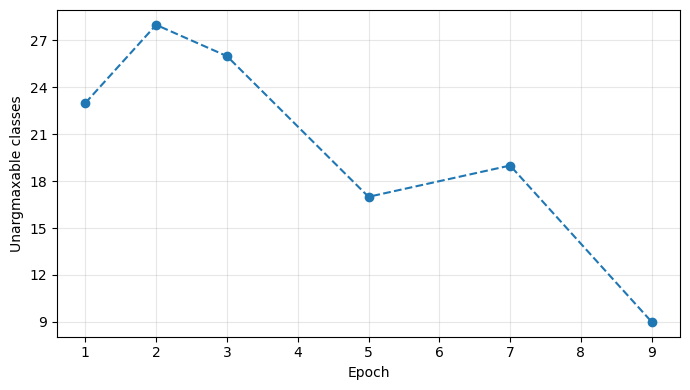

In [22]:
plt.figure(figsize=(7, 4))
#plt.scatter(x, y, label="data")
plt.plot(x, y, label="data", marker="o", linestyle="--")
#plt.plot(x_dense, y_smooth, label="interpolated", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Unargmaxable classes")
#plt.xticks(x.astype(int))
plt.grid(True, alpha=0.3)
#plt.legend()
ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig("../figures/unarg_vs_epoch.pdf", format="pdf")
plt.show()

### fig 3.2

In [23]:
raw = r'''
{"timestamp": 1774108947.490095, "relative_time": 1524.4702649116516, "current_lr": 0.001500030012, "val_time": 175.74565720558167, "top_1_8": 0.08060000091791153, "top_1_16": 0.03020000085234642, "top_1_32": 0.0608999989926815, "top_1_64": 0.04899999871850014, "top_1_128": 0.039900001138448715, "top_1_256": 0.03400000184774399, "top_1_512": 0.037300001829862595, "top_5_8": 0.15459999442100525, "top_5_16": 0.13670000433921814, "top_5_32": 0.14869999885559082, "top_5_64": 0.1193000003695488, "top_5_128": 0.0966000035405159, "top_5_256": 0.0940999984741211, "top_5_512": 0.10639999806880951, "train_loss": 34.20042419433594, "epoch": 0}
{"timestamp": 1774110452.271539, "relative_time": 3029.251708984375, "current_lr": 0.002999880012, "val_time": 174.11423087120056, "top_1_8": 0.07609999924898148, "top_1_16": 0.07150000333786011, "top_1_32": 0.07419999688863754, "top_1_64": 0.07240000367164612, "top_1_128": 0.07240000367164612, "top_1_256": 0.06589999794960022, "top_1_512": 0.06840000301599503, "top_5_8": 0.1459999978542328, "top_5_16": 0.13279999792575836, "top_5_32": 0.13570000231266022, "top_5_64": 0.1324000060558319, "top_5_128": 0.13369999825954437, "top_5_256": 0.121799997985363, "top_5_512": 0.12319999933242798, "train_loss": 30.335498809814453, "epoch": 1}
{"timestamp": 1774111957.1926558, "relative_time": 4534.1728258132935, "current_lr": 0.002571462857142857, "val_time": 174.07005548477173, "top_1_8": 0.0, "top_1_16": 0.0, "top_1_32": 0.0, "top_1_64": 0.0, "top_1_128": 0.0, "top_1_256": 0.0, "top_1_512": 0.0, "top_5_8": 0.0, "top_5_16": 0.0, "top_5_32": 0.0, "top_5_64": 0.0, "top_5_128": 0.0, "top_5_256": 0.0, "top_5_512": 0.0, "train_loss": 28.27614974975586, "epoch": 2}
{"timestamp": 1774113461.0388374, "relative_time": 6038.019007444382, "current_lr": 0.002142891428571429, "val_time": 173.369304895401, "top_1_8": 0.025100000202655792, "top_1_16": 0.03180000185966492, "top_1_32": 0.02930000051856041, "top_1_64": 0.025499999523162842, "top_1_128": 0.02410000003874302, "top_1_256": 0.02160000056028366, "top_1_512": 0.01899999938905239, "top_5_8": 0.07880000025033951, "top_5_16": 0.08489999920129776, "top_5_32": 0.08420000225305557, "top_5_64": 0.07450000196695328, "top_5_128": 0.0681999996304512, "top_5_256": 0.06239999830722809, "top_5_512": 0.05570000037550926, "train_loss": 27.08550453186035, "epoch": 3}
{"timestamp": 1774114964.2487545, "relative_time": 7541.228924512863, "current_lr": 0.0017143199999999999, "val_time": 173.2882833480835, "top_1_8": 0.044599998742341995, "top_1_16": 0.03139999881386757, "top_1_32": 0.031599998474121094, "top_1_64": 0.023600000888109207, "top_1_128": 0.021900000050663948, "top_1_256": 0.021700000390410423, "top_1_512": 0.01730000041425228, "top_5_8": 0.12290000170469284, "top_5_16": 0.11180000007152557, "top_5_32": 0.11590000241994858, "top_5_64": 0.09510000050067902, "top_5_128": 0.09220000356435776, "top_5_256": 0.09049999713897705, "top_5_512": 0.07750000059604645, "train_loss": 26.149316787719727, "epoch": 4}
{"timestamp": 1774116467.8489404, "relative_time": 9044.829110383987, "current_lr": 0.0012857485714285713, "val_time": 173.36687421798706, "top_1_8": 0.002199999988079071, "top_1_16": 0.0020000000949949026, "top_1_32": 0.00139999995008111, "top_1_64": 0.0019000000320374966, "top_1_128": 0.0012000000569969416, "top_1_256": 0.0010000000474974513, "top_1_512": 0.0010999999940395355, "top_5_8": 0.014999999664723873, "top_5_16": 0.01269999984651804, "top_5_32": 0.007799999788403511, "top_5_64": 0.007400000002235174, "top_5_128": 0.006200000178068876, "top_5_256": 0.00559999980032444, "top_5_512": 0.004900000058114529, "train_loss": 25.30105972290039, "epoch": 5}
{"timestamp": 1774117971.1323698, "relative_time": 10548.112539768219, "current_lr": 0.0008571771428571428, "val_time": 173.30158472061157, "top_1_8": 0.0006000000284984708, "top_1_16": 0.001500000013038516, "top_1_32": 0.0017000000225380063, "top_1_64": 0.0027000000700354576, "top_1_128": 0.002899999963119626, "top_1_256": 0.0026000000070780516, "top_1_512": 0.002300000051036477, "top_5_8": 0.009399999864399433, "top_5_16": 0.006099999882280827, "top_5_32": 0.00570000009611249, "top_5_64": 0.007499999832361937, "top_5_128": 0.006599999964237213, "top_5_256": 0.005799999926239252, "top_5_512": 0.005200000014156103, "train_loss": 24.972455978393555, "epoch": 6}
{"timestamp": 1774119474.3572917, "relative_time": 12051.337461709976, "current_lr": 0.00042860571428571405, "val_time": 173.51395916938782, "top_1_8": 0.002099999925121665, "top_1_16": 0.00139999995008111, "top_1_32": 0.0017000000225380063, "top_1_64": 0.002099999925121665, "top_1_128": 0.0019000000320374966, "top_1_256": 0.0013000000035390258, "top_1_512": 0.0010000000474974513, "top_5_8": 0.00839999970048666, "top_5_16": 0.006599999964237213, "top_5_32": 0.006200000178068876, "top_5_64": 0.005900000222027302, "top_5_128": 0.006099999882280827, "top_5_256": 0.005200000014156103, "top_5_512": 0.004699999932199717, "train_loss": 24.36919403076172, "epoch": 7}
{"timestamp": 1774120977.8167522, "relative_time": 13554.796922206879, "current_lr": 3.4285714285719766e-08, "val_time": 173.3012776374817, "top_1_8": 0.008500000461935997, "top_1_16": 0.00860000029206276, "top_1_32": 0.008700000122189522, "top_1_64": 0.007799999788403511, "top_1_128": 0.00800000037997961, "top_1_256": 0.007899999618530273, "top_1_512": 0.008299999870359898, "top_5_8": 0.02850000001490116, "top_5_16": 0.02250000089406967, "top_5_32": 0.022700000554323196, "top_5_64": 0.021299999207258224, "top_5_128": 0.020999999716877937, "top_5_256": 0.0210999995470047, "top_5_512": 0.021199999377131462, "train_loss": 24.62956428527832, "epoch": 8}
{"timestamp": 1774121151.2195446, "relative_time": 13728.199714660645, "current_lr": 3.4285714285719766e-08, "val_time": 173.40253829956055, "top_1_8": 0.008500000461935997, "top_1_16": 0.00860000029206276, "top_1_32": 0.008700000122189522, "top_1_64": 0.007799999788403511, "top_1_128": 0.00800000037997961, "top_1_256": 0.007899999618530273, "top_1_512": 0.008299999870359898, "top_5_8": 0.02850000001490116, "top_5_16": 0.02250000089406967, "top_5_32": 0.022700000554323196, "top_5_64": 0.021299999207258224, "top_5_128": 0.020999999716877937, "top_5_256": 0.0210999995470047, "top_5_512": 0.021199999377131462, "epoch": 8}
'''

records = [json.loads(line) for line in raw.strip().splitlines()]

seen = set()
unique = []
for rec in records:
    ep = rec["epoch"]
    if ep not in seen:
        unique.append(rec)
        seen.add(ep)

epochs_lr = [r["epoch"] for r in unique if "current_lr" in r]
lrs = [r["current_lr"] for r in unique if "current_lr" in r]

epochs_loss = [r["epoch"] for r in unique if "train_loss" in r]
losses = [r["train_loss"] for r in unique if "train_loss" in r]

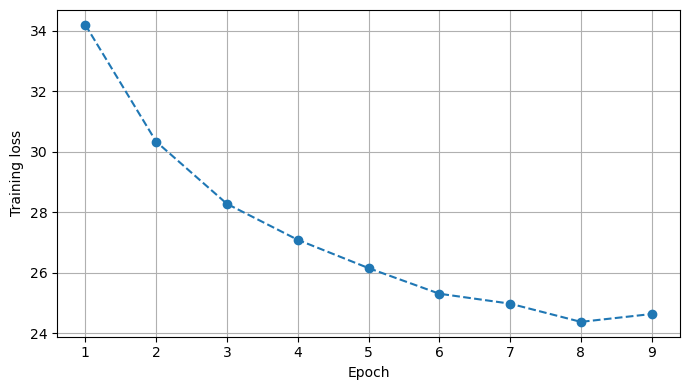

In [24]:
# training loss plot
e = list(range(1,10))
plt.figure(figsize=(7, 4))
plt.plot(e, losses, marker="o", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/resnet18_e9_train_loss.pdf", format="pdf")
plt.show()

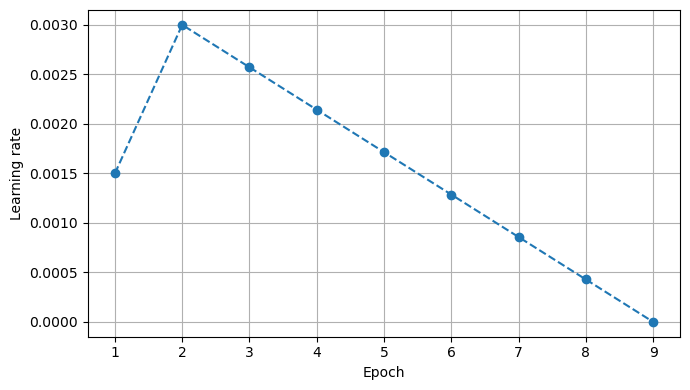

In [25]:
# learning rate plot
e = list(range(1,10))
plt.figure(figsize=(7, 4))
plt.plot(e, lrs, marker="o", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
#plt.xticks(epochs_lr)
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/resnet18_e9_learn_rate.pdf", format="pdf")
plt.show()

### fig 4

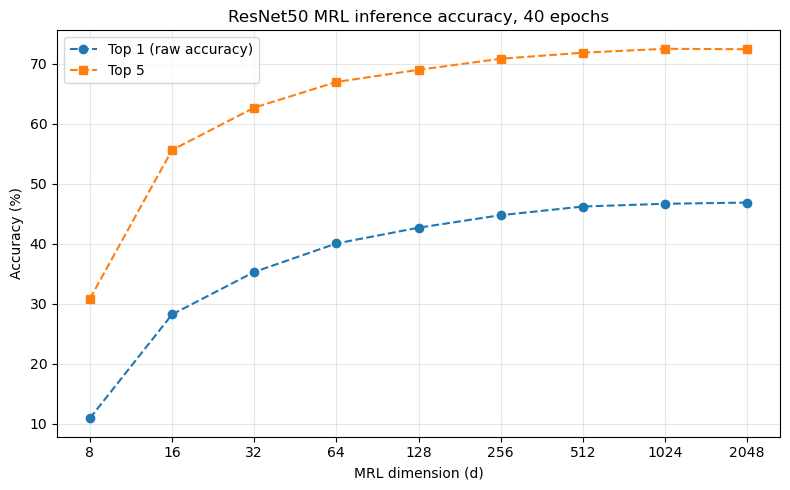

In [34]:
rep_sizes = [8, 16, 32, 64, 128, 256, 512, 1024, 2048]
top1 = [10.94, 28.24, 35.32, 40.07, 42.70, 44.79, 46.23, 46.69, 46.89]
top5 = [30.86, 55.65, 62.71, 66.99, 69.02, 70.86, 71.87, 72.52, 72.45]

plt.figure(figsize=(8, 5))
plt.plot(rep_sizes, top1, marker="o", linestyle="--", label="Top 1 (raw accuracy)")
plt.plot(rep_sizes, top5, marker="s", linestyle="--", label="Top 5")

plt.xscale("log", base=2)
plt.xticks(rep_sizes, rep_sizes)
plt.xlabel("MRL dimension (d)")
plt.ylabel("Accuracy (%)")
plt.title("ResNet50 MRL inference accuracy, 40 epochs")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/inference_resnet50_mrl_lr0.10_epochs40_labeled.pdf", format="pdf")
plt.show()